In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import shapiro

Estimated Demand Distribution

In [4]:
df = pd.read_csv('modelling_dataset_top5.csv', parse_dates=["date"])

split_date = "2017-01-01"
train_df = df[df["date"] < split_date].copy()
test_df  = df[df["date"] >= split_date].copy()

drop_cols = ["id","date","sales","log_sales"]
X_test = test_df.drop(columns=drop_cols)

In [6]:
import joblib
xgb_model = joblib.load("xgb_model.pkl")

pred_log = xgb_model.predict(X_test)
test_df["forecast_mean"] = np.expm1(pred_log)

# Forecast error
test_df["error"] = test_df["sales"] - test_df["forecast_mean"]

In [7]:
sku_forecast_stats = (
    test_df.groupby(["store_nbr","family"])
    .agg(
        forecast_mean=("forecast_mean","mean"),
        forecast_std=("error","std"),   # std of residuals = uncertainty
        actual_mean=("sales","mean"),
        actual_std=("sales","std")
    )
    .reset_index()
)

sku_forecast_stats["forecast_std"] = sku_forecast_stats["forecast_std"].fillna(0.0)
sku_forecast_stats.head()

,store_nbr,family,forecast_mean,forecast_std,actual_mean,actual_std
0,1,BEVERAGES,2066.354492,410.063072,2172.792952,609.263371
1,1,CLEANING,642.261353,127.404324,662.352423,224.950770
2,1,DAIRY,705.777039,115.772332,725.775330,204.637923
3,1,GROCERY I,2501.321045,506.120675,2614.387665,784.822538
4,1,PRODUCE,2358.864014,407.898018,2506.538398,904.681184


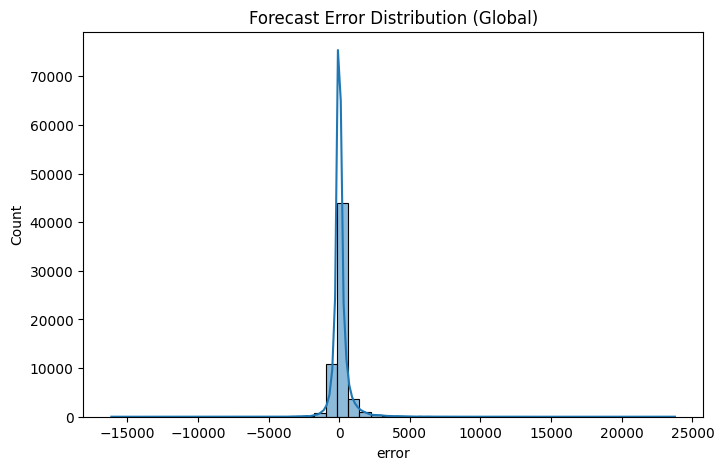

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(test_df["error"], bins=50, kde=True)
plt.title("Forecast Error Distribution (Global)")
plt.show()

In [9]:
sample_errors = test_df["error"].dropna().sample(5000, random_state=42)
stat, p = shapiro(sample_errors)
print("Shapiro p-value:", p)

Shapiro p-value: 5.850544677918615e-76


Safety Stock Calculations

In [10]:
LEAD_TIME_DAYS = 7

In [11]:
segmentation = pd.read_csv("segmentation.csv")
segmentation["segment"] = segmentation["ABC_class"] + segmentation["XYZ_class"]

sl_map = {
    "AX":0.98, "AY":0.97, "AZ":0.95,
    "BX":0.95, "BY":0.93, "BZ":0.90,
    "CX":0.90, "CY":0.85, "CZ":0.80
}
segmentation["service_level"] = segmentation["segment"].map(sl_map).fillna(0.90)

In [12]:
policy = sku_forecast_stats.merge(
    segmentation[["store_nbr","family","segment","service_level"]],
    on=["store_nbr","family"],
    how="left"
)

policy["service_level"] = policy["service_level"].fillna(0.95)
policy["lead_time_days"] = LEAD_TIME_DAYS

In [13]:
policy["z"] = policy["service_level"].apply(norm.ppf)
policy["safety_stock"] = policy["z"] * policy["forecast_std"] * np.sqrt(policy["lead_time_days"])

policy["safety_stock"] = policy["safety_stock"].clip(lower=0)
policy.head()

,store_nbr,family,forecast_mean,forecast_std,actual_mean,actual_std,segment,service_level,lead_time_days,z,safety_stock
0,1,BEVERAGES,2066.354492,410.063072,2172.792952,609.263371,BX,0.95,7,1.644854,1784.542676
1,1,CLEANING,642.261353,127.404324,662.352423,224.950770,CX,0.90,7,1.281552,431.985604
2,1,DAIRY,705.777039,115.772332,725.775330,204.637923,CX,0.90,7,1.281552,392.545396
3,1,GROCERY I,2501.321045,506.120675,2614.387665,784.822538,AX,0.98,7,2.053749,2750.112402
4,1,PRODUCE,2358.864014,407.898018,2506.538398,904.681184,BY,0.93,7,1.475791,1592.668829


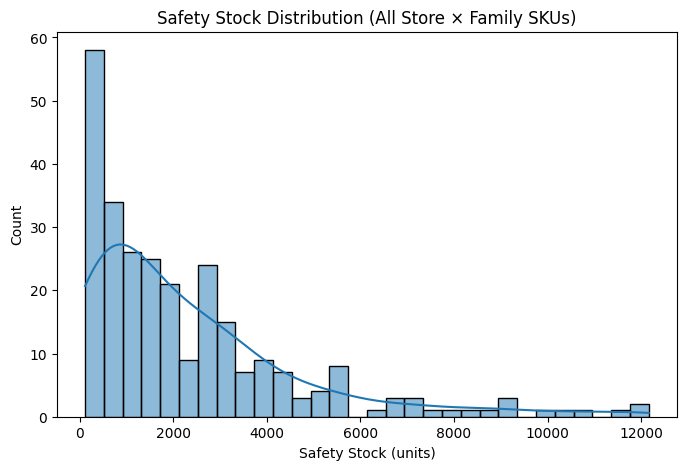

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(policy["safety_stock"], bins=30, kde=True)
plt.title("Safety Stock Distribution (All Store × Family SKUs)")
plt.xlabel("Safety Stock (units)")
plt.show()

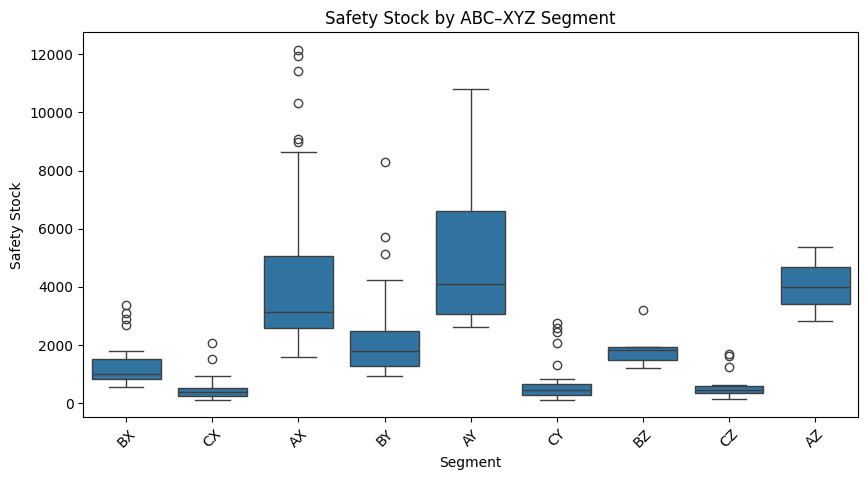

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(data=policy, x="segment", y="safety_stock")
plt.title("Safety Stock by ABC–XYZ Segment")
plt.xlabel("Segment")
plt.ylabel("Safety Stock")
plt.xticks(rotation=45)
plt.show()

Reorder Point 

In [15]:
policy["ROP"] = policy["forecast_mean"] * policy["lead_time_days"] + policy["safety_stock"]
policy["ROP"] = policy["ROP"].clip(lower=0)

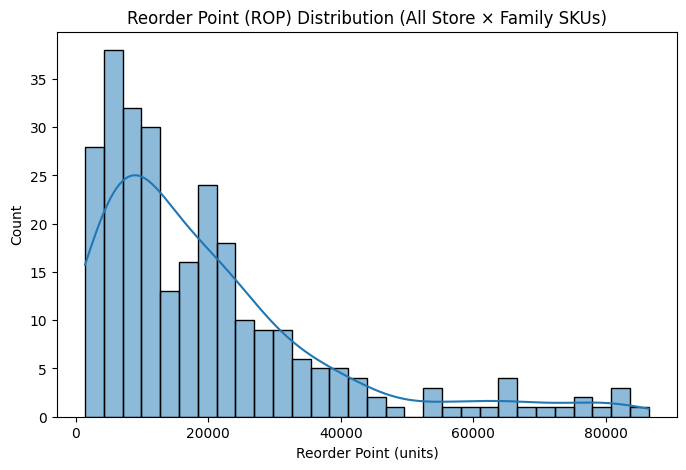

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(policy["ROP"], bins=30, kde=True)
plt.title("Reorder Point (ROP) Distribution (All Store × Family SKUs)")
plt.xlabel("Reorder Point (units)")
plt.show()

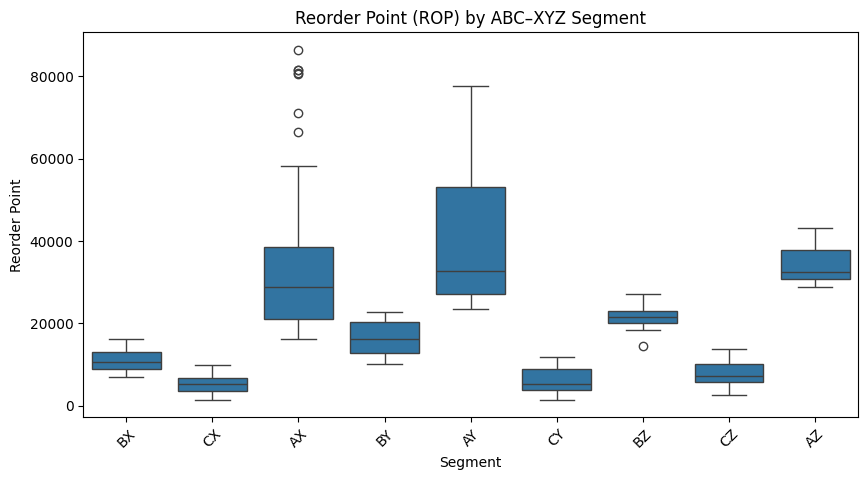

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=policy, x="segment", y="ROP")
plt.title("Reorder Point (ROP) by ABC–XYZ Segment")
plt.xlabel("Segment")
plt.ylabel("Reorder Point")
plt.xticks(rotation=45)
plt.show()

Economic Order Quantity

In [16]:
ORDER_COST = 50          # $ per order (assumption)
HOLDING_RATE = 0.20      # 20% annual holding cost rate
UNIT_COST = 1.0          # unknown -> use 1, EOQ in "units"
H = UNIT_COST * HOLDING_RATE

In [17]:
policy["annual_demand"] = policy["forecast_mean"] * 365
policy["EOQ"] = np.sqrt((2 * policy["annual_demand"] * ORDER_COST) / H)
policy["EOQ"] = policy["EOQ"].replace([np.inf, -np.inf], np.nan).fillna(0)

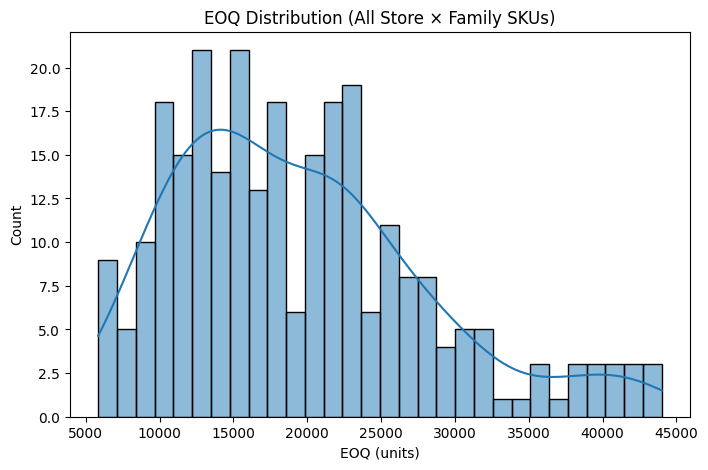

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(policy["EOQ"], bins=30, kde=True)
plt.title("EOQ Distribution (All Store × Family SKUs)")
plt.xlabel("EOQ (units)")
plt.show()

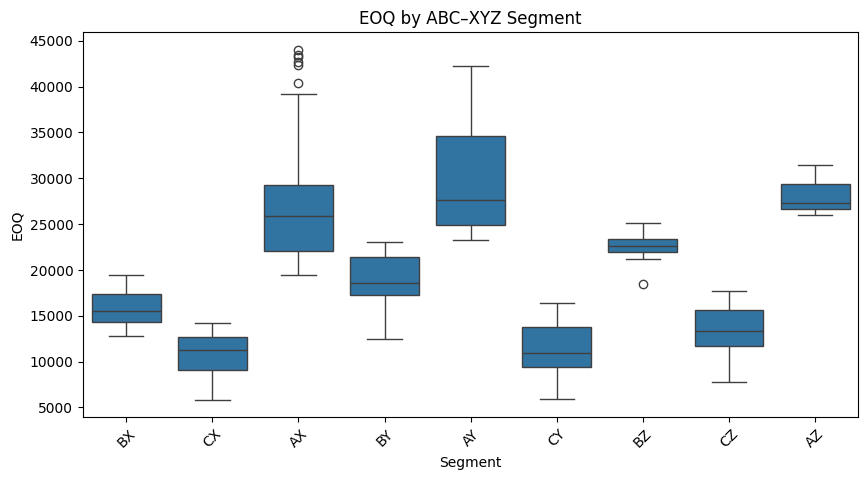

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(data=policy, x="segment", y="EOQ")
plt.title("EOQ by ABC–XYZ Segment")
plt.xlabel("Segment")
plt.ylabel("EOQ")
plt.xticks(rotation=45)
plt.show()

Service Level Simulation

In [18]:
# Helper Simulation Function
def simulate_policy(mu_daily, sigma_daily, rop, lead_time_mean=7, lead_time_std=2,
                    reps=10000, demand_spike=0.0, sigma_multiplier=1.0, seed=42):
    rng = np.random.default_rng(seed)

    # sample lead time (integer days)
    L = rng.normal(lead_time_mean, lead_time_std, size=reps)
    L = np.clip(np.round(L), 1, 21)

    # adjusted demand mean and sigma
    mu_adj = mu_daily * (1 + demand_spike)
    sigma_adj = sigma_daily * sigma_multiplier

    # simulate lead time demand
    demand_L = rng.normal(loc=mu_adj * L, scale=np.sqrt(L) * sigma_adj)

    # stockout probability
    stockout = demand_L > rop
    stockout_prob = stockout.mean()

    # approximate fill rate: 1 - expected shortage / expected demand
    shortage = np.maximum(demand_L - rop, 0)
    fill_rate = 1 - (shortage.mean() / (np.maximum(demand_L.mean(), 1e-9)))

    return stockout_prob, fill_rate

In [19]:
# RUn simulation for top N SKU
policy_sorted = policy.sort_values("annual_demand", ascending=False).head(50).copy()

In [20]:
# Base Scenario: fised lead time, no spike, normal variance
base_results = []
for _, r in policy_sorted.iterrows():
    p_stockout, fill = simulate_policy(
        mu_daily=r["forecast_mean"],
        sigma_daily=r["forecast_std"],
        rop=r["ROP"],
        lead_time_mean=LEAD_TIME_DAYS,
        lead_time_std=0,          # fixed lead time base
        demand_spike=0.0,
        sigma_multiplier=1.0
    )
    base_results.append((p_stockout, fill))

policy_sorted["stockout_prob_base"] = [x[0] for x in base_results]
policy_sorted["fill_rate_base"] = [x[1] for x in base_results]

In [21]:
# Scenario 1: Lead time Variablity
ltv_results = []
for _, r in policy_sorted.iterrows():
    p_stockout, fill = simulate_policy(
        mu_daily=r["forecast_mean"],
        sigma_daily=r["forecast_std"],
        rop=r["ROP"],
        lead_time_mean=LEAD_TIME_DAYS,
        lead_time_std=2,
        demand_spike=0.0,
        sigma_multiplier=1.0
    )
    ltv_results.append((p_stockout, fill))

policy_sorted["stockout_prob_ltvar"] = [x[0] for x in ltv_results]
policy_sorted["fill_rate_ltvar"] = [x[1] for x in ltv_results]

In [22]:
# +20% demand spike
spike_results = []
for _, r in policy_sorted.iterrows():
    p_stockout, fill = simulate_policy(
        mu_daily=r["forecast_mean"],
        sigma_daily=r["forecast_std"],
        rop=r["ROP"],
        lead_time_mean=LEAD_TIME_DAYS,
        lead_time_std=0,
        demand_spike=0.20,
        sigma_multiplier=1.0
    )
    spike_results.append((p_stockout, fill))

policy_sorted["stockout_prob_spike20"] = [x[0] for x in spike_results]
policy_sorted["fill_rate_spike20"] = [x[1] for x in spike_results]

In [23]:
# Increased variance (+50%)
var_results = []
for _, r in policy_sorted.iterrows():
    p_stockout, fill = simulate_policy(
        mu_daily=r["forecast_mean"],
        sigma_daily=r["forecast_std"],
        rop=r["ROP"],
        lead_time_mean=LEAD_TIME_DAYS,
        lead_time_std=0,
        demand_spike=0.0,
        sigma_multiplier=1.5
    )
    var_results.append((p_stockout, fill))

policy_sorted["stockout_prob_var50"] = [x[0] for x in var_results]
policy_sorted["fill_rate_var50"] = [x[1] for x in var_results]

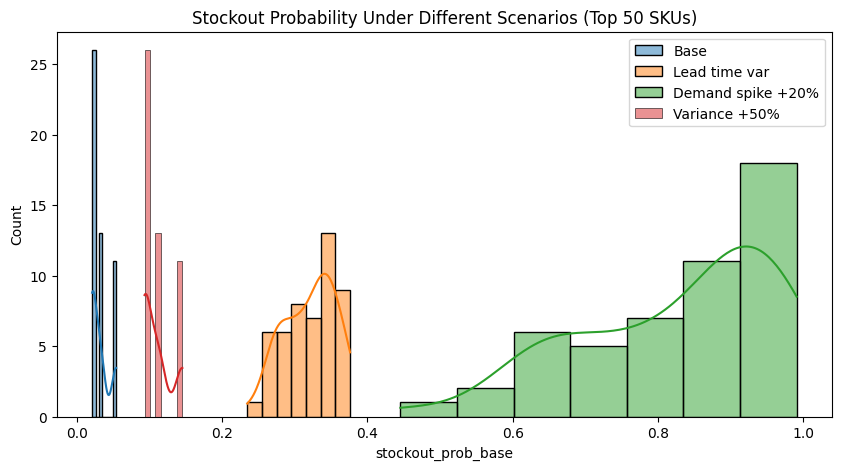

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(policy_sorted["stockout_prob_base"], label="Base", kde=True)
sns.histplot(policy_sorted["stockout_prob_ltvar"], label="Lead time var", kde=True)
sns.histplot(policy_sorted["stockout_prob_spike20"], label="Demand spike +20%", kde=True)
sns.histplot(policy_sorted["stockout_prob_var50"], label="Variance +50%", kde=True)
plt.legend()
plt.title("Stockout Probability Under Different Scenarios (Top 50 SKUs)")
plt.show()

Cost Impact

In [25]:
STOCKOUT_COST = 5.0  # assumption: lost margin / penalty per unit

In [26]:
policy_sorted["annual_holding_cost"] = policy_sorted["safety_stock"] * H

In [27]:
# Expected annual demand
policy_sorted["annual_demand"] = policy_sorted["forecast_mean"] * 365

# Approx expected annual lost units = (1 - fill_rate) * annual demand
policy_sorted["annual_lost_units_base"] = (1 - policy_sorted["fill_rate_base"]) * policy_sorted["annual_demand"]
policy_sorted["annual_stockout_cost_base"] = policy_sorted["annual_lost_units_base"] * STOCKOUT_COST

policy_sorted[["annual_holding_cost","annual_stockout_cost_base"]].describe()

,annual_holding_cost,annual_stockout_cost_base
count,50.000000,50.000000
mean,1174.850743,9244.051364
std,522.303969,5726.987344
min,527.052029,2584.853591
25%,793.135609,4445.454861
50%,1056.056809,8003.412188
75%,1422.989157,12536.641772
max,2431.838194,25119.262432


Final Deliverible

In [28]:
final_policy = policy[[
    "store_nbr","family","segment",
    "forecast_mean","forecast_std",
    "service_level","lead_time_days",
    "safety_stock","ROP","EOQ"
]].copy()

final_policy.to_csv("inventory_policy_recommendations.csv", index=False)
print("Saved: inventory_policy_recommendations.csv")

Saved: inventory_policy_recommendations.csv


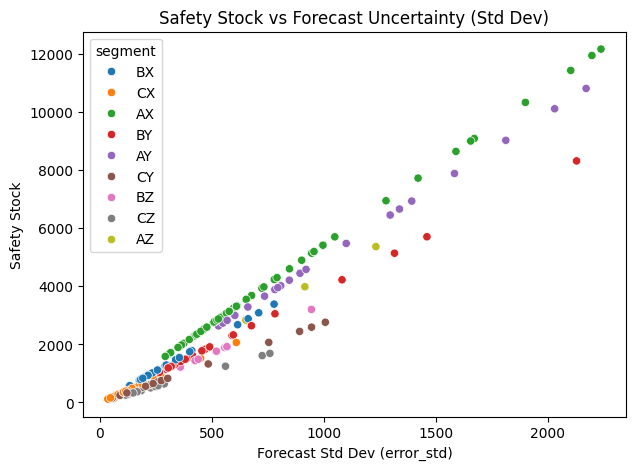

In [35]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=policy, x="forecast_std", y="safety_stock", hue="segment")
plt.title("Safety Stock vs Forecast Uncertainty (Std Dev)")
plt.xlabel("Forecast Std Dev (error_std)")
plt.ylabel("Safety Stock")
plt.show()

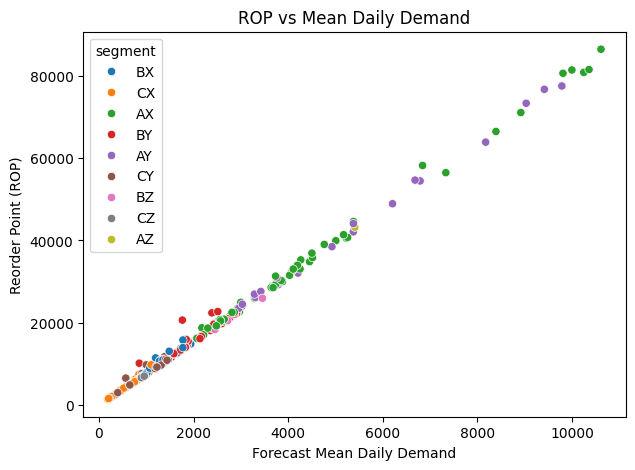

In [36]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=policy, x="forecast_mean", y="ROP", hue="segment")
plt.title("ROP vs Mean Daily Demand")
plt.xlabel("Forecast Mean Daily Demand")
plt.ylabel("Reorder Point (ROP)")
plt.show()

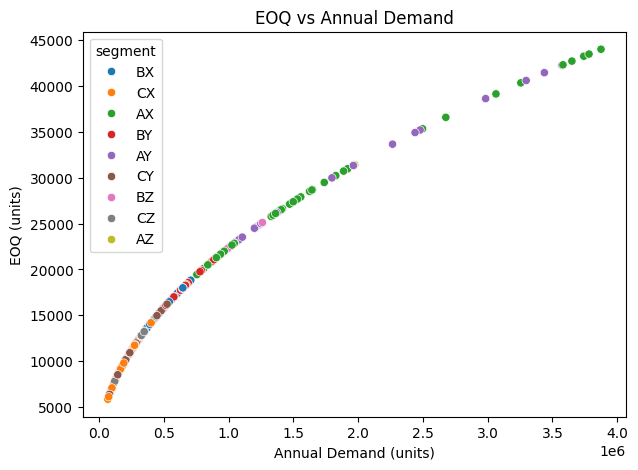

In [37]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=policy, x="annual_demand", y="EOQ", hue="segment")
plt.title("EOQ vs Annual Demand")
plt.xlabel("Annual Demand (units)")
plt.ylabel("EOQ (units)")
plt.show()

In [38]:
policy.sort_values("safety_stock", ascending=False).head(10)[
    ["store_nbr","family","segment","forecast_mean","forecast_std","service_level","safety_stock","ROP","EOQ"]
]

,store_nbr,family,segment,forecast_mean,forecast_std,service_level,safety_stock,ROP,EOQ
223,45,GROCERY I,AX,10615.126953,2237.733242,0.98,12159.190972,86465.079644,44014.324219
228,46,GROCERY I,AX,9811.319336,2197.131804,0.98,11938.574579,80617.809930,42315.078125
215,44,BEVERAGES,AX,9999.905273,2102.599240,0.98,11424.912148,81424.249062,42719.816406
220,45,BEVERAGES,AY,9417.630859,2171.283424,0.97,10804.549835,76727.965851,41457.417969
43,9,GROCERY I,AX,6842.267578,1900.132866,0.98,10324.768816,58220.641863,35337.144531
230,47,BEVERAGES,AY,9032.902344,2030.845375,0.97,10105.714352,73336.030759,40601.781250
218,44,GROCERY I,AX,10250.869141,1671.743464,0.98,9083.767291,80839.851276,43252.554688
219,44,PRODUCE,AY,9787.779297,1812.623644,0.97,9019.818547,77534.273625,42264.285156
233,47,GROCERY I,AX,10361.619141,1655.697557,0.98,8996.578508,81527.912492,43485.578125
10,3,BEVERAGES,AX,8920.208984,1589.887599,0.98,8638.986354,71080.449245,40347.714844


In [39]:
policy.sort_values("ROP", ascending=False).head(10)[
    ["store_nbr","family","segment","forecast_mean","forecast_std","service_level","safety_stock","ROP","EOQ"]
]

,store_nbr,family,segment,forecast_mean,forecast_std,service_level,safety_stock,ROP,EOQ
223,45,GROCERY I,AX,10615.126953,2237.733242,0.98,12159.190972,86465.079644,44014.324219
233,47,GROCERY I,AX,10361.619141,1655.697557,0.98,8996.578508,81527.912492,43485.578125
215,44,BEVERAGES,AX,9999.905273,2102.599240,0.98,11424.912148,81424.249062,42719.816406
218,44,GROCERY I,AX,10250.869141,1671.743464,0.98,9083.767291,80839.851276,43252.554688
228,46,GROCERY I,AX,9811.319336,2197.131804,0.98,11938.574579,80617.809930,42315.078125
219,44,PRODUCE,AY,9787.779297,1812.623644,0.97,9019.818547,77534.273625,42264.285156
220,45,BEVERAGES,AY,9417.630859,2171.283424,0.97,10804.549835,76727.965851,41457.417969
230,47,BEVERAGES,AY,9032.902344,2030.845375,0.97,10105.714352,73336.030759,40601.781250
10,3,BEVERAGES,AX,8920.208984,1589.887599,0.98,8638.986354,71080.449245,40347.714844
238,48,GROCERY I,NaN,8598.506836,1648.198194,0.95,7172.750275,67362.298127,39613.476562


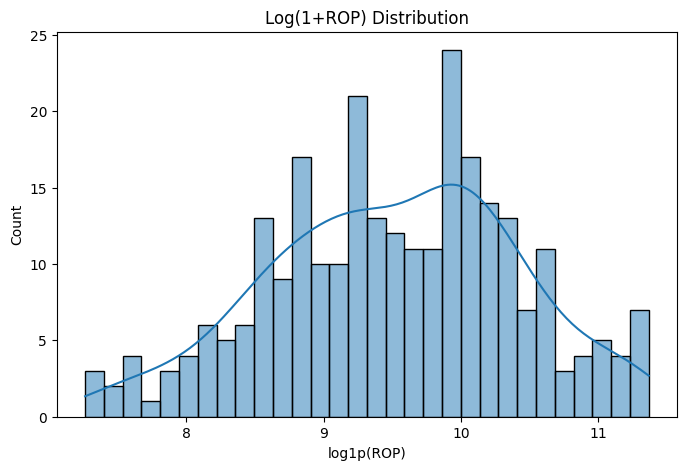

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(policy["ROP"]), bins=30, kde=True)
plt.title("Log(1+ROP) Distribution")
plt.xlabel("log1p(ROP)")
plt.show()